# 02 -- SuperStore Cleaning and Feature Engineering

**Project:** SuperStore Retail Performance & Profitability Analysis  
**Workflow:** Clean from raw data and export the exact 37-column Tableau schema  
**Goal:** Rebuild the final dataset from scratch without adding unwanted helper columns to the saved CSV.

## 1. Environment Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "SuperStore_Analysis/Tableau_Analysis/scripts/superstore_pipeline.py").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root from the notebook environment.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from SuperStore_Analysis.Tableau_Analysis.scripts.superstore_pipeline import (
    FINAL_SCHEMA,
    LOYAL_CUSTOMER_MIN_PURCHASES,
    build_clean_dataset,
    build_tableau_ready_dataset,
    compute_project_metrics,
    copy_raw_snapshot,
    export_pipeline_outputs,
    load_existing_cleaned_dataset,
    load_raw_dataset,
    prepare_analysis_frame,
    resolve_project_paths,
    validate_final_schema,
)

PATHS = resolve_project_paths(REPO_ROOT / "SuperStore_Analysis" / "Tableau_Analysis")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


## 2. Build the Cleaned Dataset from Raw Data

In [2]:
df_raw = load_raw_dataset(PATHS)
df_clean, dropped_row_ids = build_clean_dataset(df_raw=df_raw, paths=PATHS)
display(df_clean.head(10))
print("Dropped duplicate Row ID(s):", dropped_row_ids)


,Row ID,Transaction Id (PK),Order ID,Order Date,Year,Month,Quarter,Ship Date,Shipping Delay,Shipping Speed,Ship Mode,Customer ID,Customer Name,Customer Type,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Order-Size,Sales Per Unit,Discount,Profit,Profit Margin,Loss Severity,Loss Flag,Order-Level Total Sales (Grouped by Order ID C),Customer Purchase Frequency (Customer ID = L),Total sales per customer,Discount Amount (Sales × Discount)
0,1,TXN-000001,CA-2016-152156,11/8/2016,2016,November,Q4,11/11/2016,3,Fast,Second Class,CG-12520,Claire Gute,Occasional,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,FURNITURE,Bookcases,Bush Somerset Collection Bookcase,261.96,2,Medium,130.98,0%,41.91,0.16,Profit,Profit,993.90,5,"1,148.78",0.00
1,2,TXN-000002,CA-2016-152156,11/8/2016,2016,November,Q4,11/11/2016,3,Fast,Second Class,CG-12520,Claire Gute,Occasional,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,FURNITURE,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,Large,243.98,0%,219.58,0.30,Profit,Profit,993.90,5,"1,148.78",0.00
2,3,TXN-000003,CA-2016-138688,6/12/2016,2016,June,Q2,6/16/2016,4,Normal,Second Class,DV-13045,Darrin Van Huff,Occasional,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,OFFICE SUPPLIES,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,Small,7.31,0%,6.87,0.47,Profit,Profit,14.62,9,"1,119.48",0.00
3,4,TXN-000004,US-2015-108966,10/11/2015,2015,October,Q4,10/18/2015,7,Slow,Standard Class,SO-20335,Sean O'Donnell,Loyal,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,FURNITURE,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,Large,191.52,45%,-383.03,-0.40,High Loss,Loss,979.95,15,"2,602.58",430.91
4,5,TXN-000005,US-2015-108966,10/11/2015,2015,October,Q4,10/18/2015,7,Slow,Standard Class,SO-20335,Sean O'Donnell,Loyal,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,OFFICE SUPPLIES,Storage,Eldon Fold 'N Roll Cart System,22.37,2,Small,11.18,20%,2.52,0.11,Profit,Profit,979.95,15,"2,602.58",4.47
5,6,TXN-000006,CA-2014-115812,6/9/2014,2014,June,Q2,6/14/2014,5,Normal,Standard Class,BH-11710,Brosina Hoffman,Loyal,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,FURNITURE,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,Small,6.98,0%,14.17,0.29,Profit,Profit,"3,714.29",24,"6,255.33",0.00
6,7,TXN-000007,CA-2014-115812,6/9/2014,2014,June,Q2,6/14/2014,5,Normal,Standard Class,BH-11710,Brosina Hoffman,Loyal,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,OFFICE SUPPLIES,Art,Newell 322,7.28,4,Small,1.82,0%,1.97,0.27,Profit,Profit,"3,714.29",24,"6,255.33",0.00
7,8,TXN-000008,CA-2014-115812,6/9/2014,2014,June,Q2,6/14/2014,5,Normal,Standard Class,BH-11710,Brosina Hoffman,Loyal,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,TECHNOLOGY,Phones,Mitel 5320 IP Phone VoIP phone,907.15,6,Large,151.19,20%,90.72,0.10,Profit,Profit,"3,714.29",24,"6,255.33",181.43
8,9,TXN-000009,CA-2014-115812,6/9/2014,2014,June,Q2,6/14/2014,5,Normal,Standard Class,BH-11710,Brosina Hoffman,Loyal,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,OFFICE SUPPLIES,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3,Small,6.17,20%,5.78,0.31,Profit,Profit,"3,714.29",24,"6,255.33",3.70
9,10,TXN-000010,CA-2014-115812,6/9/2014,2014,June,Q2,6/14/2014,5,Normal,Standard Class,BH-11710,Brosina Hoffman,Loyal,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,OFFICE SUPPLIES,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.90,5,Medium,22.98,0%,34.47,0.30,Profit,Profit,"3,714.29",24,"6,255.33",0.00


Dropped duplicate Row ID(s): [3407]


## 3. Schema and QA Validation

In [3]:
schema_check = validate_final_schema(df_clean)
metrics = compute_project_metrics(df_clean)
qa_table = pd.DataFrame({
    "Check": [
        "Schema matches approved 37-column layout",
        "Row count after duplicate removal",
        "Total sales",
        "Total profit",
        "Overall profit margin",
        "Loss transactions",
        "High-discount transactions (>20%)",
        "Unique orders",
        "Unique customers",
        "Unique products",
    ],
    "Value": [
        schema_check["matches_expected_schema"],
        metrics["rows"],
        f"${metrics['sales_total']:,.2f}",
        f"${metrics['profit_total']:,.2f}",
        f"{metrics['profit_margin'] * 100:.2f}%",
        metrics["loss_transactions"],
        metrics["high_discount_transactions"],
        metrics["unique_orders"],
        metrics["unique_customers"],
        metrics["unique_products"],
    ],
})
display(qa_table)
print(schema_check)


,Check,Value
0,Schema matches approved 37-column layout,True
1,Row count after duplicate removal,9993
2,Total sales,"$2,296,919.28"
3,Total profit,"$286,408.60"
4,Overall profit margin,12.47%
5,Loss transactions,1870
6,High-discount transactions (>20%),1392
7,Unique orders,5009
8,Unique customers,793
9,Unique products,1862


{'matches_expected_schema': True, 'missing_columns': [], 'unexpected_columns': []}


## 4. Feature Logic Snapshot

In [4]:
feature_notes = pd.DataFrame({
    "Field": [
        "Transaction Id (PK)",
        "Shipping Speed",
        "Customer Type",
        "Order-Size",
        "Profit Margin",
        "Loss Severity",
    ],
    "Logic": [
        "Sequential key: TXN-000001 onward after sorting by Row ID",
        "Fast <= 3 days, Normal = 4 to 6 days, Slow >= 7 days",
        f"Loyal if purchase frequency >= {LOYAL_CUSTOMER_MIN_PURCHASES}, otherwise Occasional",
        "Small < 100, Medium = 100 to 499.99, Large >= 500",
        "Profit / Sales rounded to 2 decimals",
        "Profit, Low Loss (-200 < Profit < 0), High Loss (Profit <= -200)",
    ],
})
display(feature_notes)


,Field,Logic
0,Transaction Id (PK),Sequential key: TXN-000001 onward after sortin...
1,Shipping Speed,"Fast <= 3 days, Normal = 4 to 6 days, Slow >= ..."
2,Customer Type,"Loyal if purchase frequency >= 10, otherwise O..."
3,Order-Size,"Small < 100, Medium = 100 to 499.99, Large >= 500"
4,Profit Margin,Profit / Sales rounded to 2 decimals
5,Loss Severity,"Profit, Low Loss (-200 < Profit < 0), High Los..."


## 5. Distribution Checks

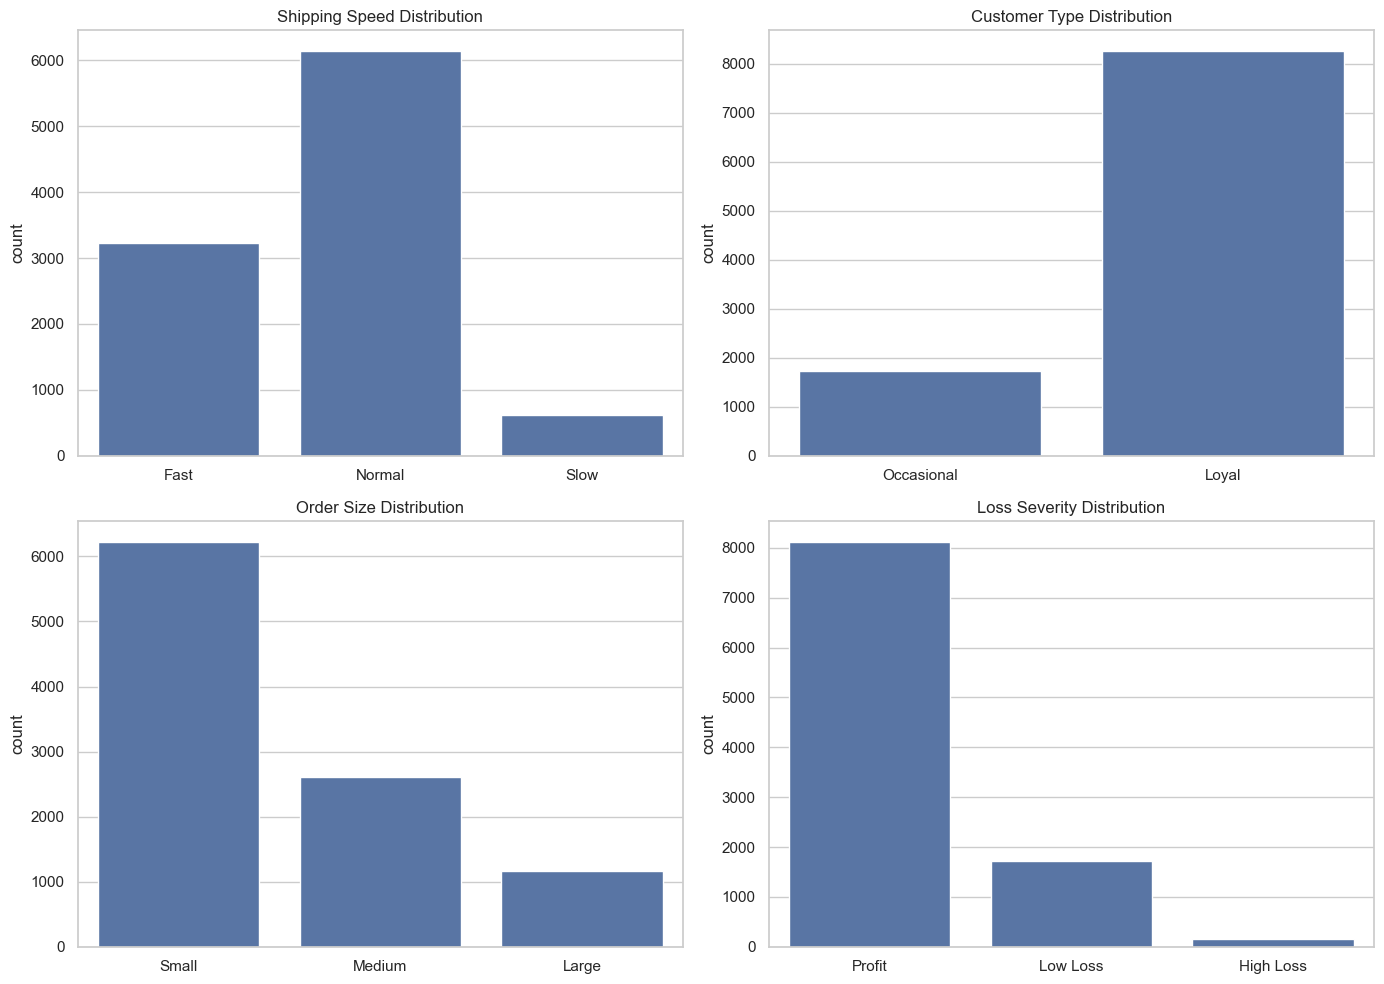

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_clean, x="Shipping Speed", order=["Fast", "Normal", "Slow"], ax=axes[0, 0])
axes[0, 0].set_title("Shipping Speed Distribution")
axes[0, 0].set_xlabel("")

sns.countplot(data=df_clean, x="Customer Type", order=["Occasional", "Loyal"], ax=axes[0, 1])
axes[0, 1].set_title("Customer Type Distribution")
axes[0, 1].set_xlabel("")

sns.countplot(data=df_clean, x="Order-Size", order=["Small", "Medium", "Large"], ax=axes[1, 0])
axes[1, 0].set_title("Order Size Distribution")
axes[1, 0].set_xlabel("")

sns.countplot(data=df_clean, x="Loss Severity", order=["Profit", "Low Loss", "High Loss"], ax=axes[1, 1])
axes[1, 1].set_title("Loss Severity Distribution")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()


## 6. Export the Processed Files

In [6]:
df_clean_exported, df_tableau_exported, dropped_row_ids = export_pipeline_outputs(paths=PATHS)
export_summary = pd.DataFrame({
    "File": ["Raw snapshot", "Processed cleaned dataset", "Final Tableau-ready dataset"],
    "Path": [
        str(PATHS.raw_snapshot_path),
        str(PATHS.cleaned_output_path),
        str(PATHS.tableau_output_path),
    ],
    "Rows": [len(load_raw_dataset(PATHS)), len(df_clean_exported), len(df_tableau_exported)],
})
display(export_summary)


,File,Path,Rows
0,Raw snapshot,/Users/ravleensingh/Documents/Capstone/DVA_Cap...,9994
1,Processed cleaned dataset,/Users/ravleensingh/Documents/Capstone/DVA_Cap...,9993
2,Final Tableau-ready dataset,/Users/ravleensingh/Documents/Capstone/DVA_Cap...,9993


## 7. Cleaning Takeaways

- The Tableau workflow now exports only the approved 37 columns.
- The raw duplicate business row with `Row ID = 3407` is removed reproducibly.
- The dataset is ready for EDA and Tableau Public without polluting the final CSV with notebook-only helper fields.